In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np

SRC_PATH = Path.cwd().parent / 'src'
sys.path.insert(0, str(SRC_PATH))

print(f"Adding to path: {SRC_PATH}")
print(f"Path exists: {SRC_PATH.exists()}")

from plotting import DataPlotter
plotter = DataPlotter(figsize_default=(10, 6))

from utils import statistical_summary, print_basic_info

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Adding to path: /home/moh/ws_idea/Higgs Boson Detection/src
Path exists: True


## Load Data & Basic Info

In [2]:
higgs_dataframe_path = "../data/raw/higgs-uci-dataset/HIGGS.csv"
higgs_dataframe = pd.read_csv(higgs_dataframe_path, names=["label"] + [f"low_feature_{i}" if i < 22 else f"high_feature_{i}" for i in range(1, 29)])
X = higgs_dataframe.drop("label", axis=1).values
y = higgs_dataframe["label"].values

In [4]:
print_basic_info(higgs_dataframe)

First 5 rows of the dataset:
   label  low_feature_1  low_feature_2  low_feature_3  low_feature_4  \
0    1.0       0.869293      -0.635082       0.225690       0.327470   
1    1.0       0.907542       0.329147       0.359412       1.497970   
2    1.0       0.798835       1.470639      -1.635975       0.453773   
3    0.0       1.344385      -0.876626       0.935913       1.992050   
4    1.0       1.105009       0.321356       1.522401       0.882808   

   low_feature_5  low_feature_6  low_feature_7  low_feature_8  low_feature_9  \
0      -0.689993       0.754202      -0.248573      -1.092064       0.000000   
1      -0.313010       1.095531      -0.557525      -1.588230       2.173076   
2       0.425629       1.104875       1.282322       1.381664       0.000000   
3       0.882454       1.786066      -1.646778      -0.942383       0.000000   
4      -1.205349       0.681466      -1.070464      -0.921871       0.000000   

   ...  low_feature_19  low_feature_20  low_feature_21  h

## Check for Missing Values

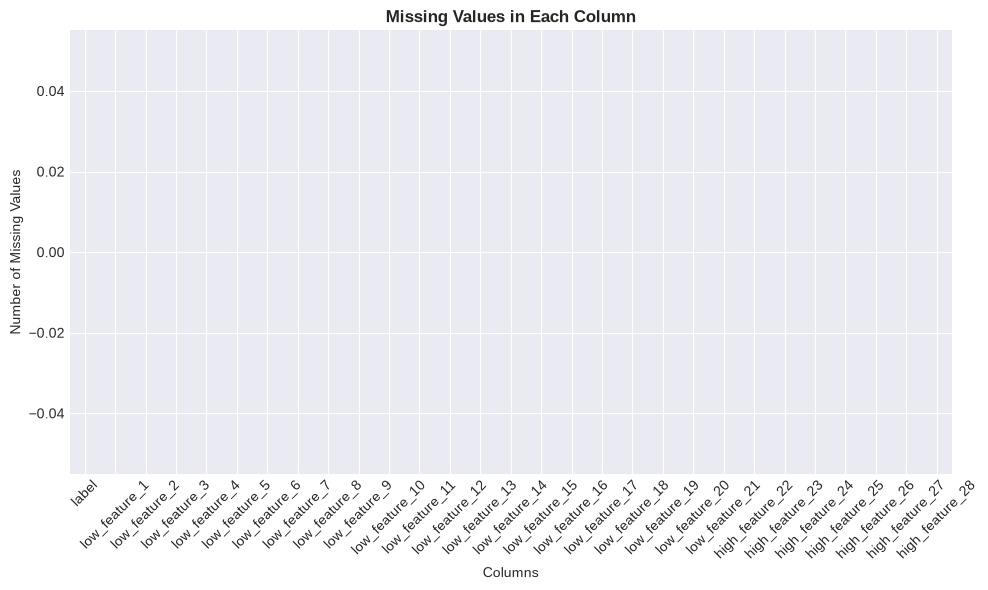

Missing values in each column:
label              0
low_feature_1      0
low_feature_2      0
low_feature_3      0
low_feature_4      0
low_feature_5      0
low_feature_6      0
low_feature_7      0
low_feature_8      0
low_feature_9      0
low_feature_10     0
low_feature_11     0
low_feature_12     0
low_feature_13     0
low_feature_14     0
low_feature_15     0
low_feature_16     0
low_feature_17     0
low_feature_18     0
low_feature_19     0
low_feature_20     0
low_feature_21     0
high_feature_22    0
high_feature_23    0
high_feature_24    0
high_feature_25    0
high_feature_26    0
high_feature_27    0
high_feature_28    0
dtype: int64


In [ ]:
missing_values = higgs_dataframe.isnull().sum()
plotter.plot_missing_values(missing_values)
print(f"Missing values in each column:\n{missing_values}")


## Class Distribution

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/home/moh/ws_idea/Higgs Boson Detection/src/plotting.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Background (0)", "Signal (1)"])


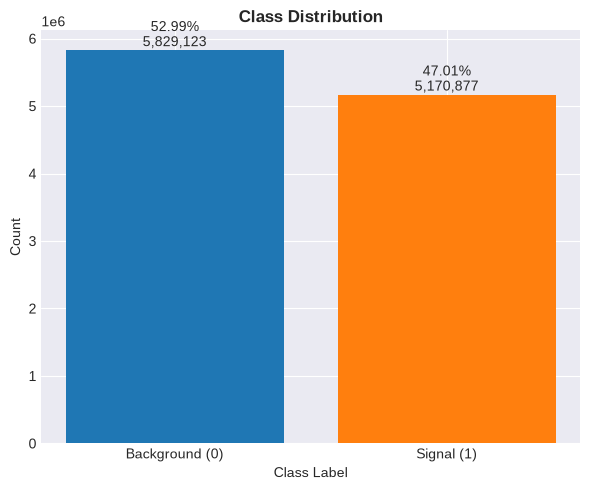

Class distribution:
label
1.0    5829123
0.0    5170877
Name: count, dtype: int64
Class distribution percentages:
label
1.0    52.99
0.0    47.01
Name: count, dtype: float64


In [20]:
counts = higgs_dataframe['label'].value_counts()
percentages = (counts / len(higgs_dataframe) * 100).round(2)

plotter.plot_class_distribution(counts, percentages)
print(f"Class distribution:\n{counts}")
print(f"Class distribution percentages:\n{percentages}")


## Analyze Feature Variance

Variance of each feature after normalization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]
Mean of each feature after normalization:
[-1.42335921e-16  8.54718316e-18  1.96161471e-17  1.19887938e-17
 -2.74915444e-17 -1.29230929e-16  8.18545232e-18 -2.06599990e-17
 -1.92234107e-17 -4.22501630e-17 -2.19105542e-18  2.83596984e-17
  1.66768256e-16 -5.58925835e-17 -1.84172677e-17  4.35007182e-17
  6.20316727e-17 -1.24848818e-17  3.79300631e-18  3.03957263e-17
  3.80334148e-17 -9.26961134e-17 -3.14519804e-16 -2.82770171e-17
  1.21396872e-16 -1.40826986e-16  6.31685411e-17  4.41001579e-17]
Max of each feature after normalization:
[19.64606808  2.4135728   1.73225583 23.99640264  1.73227227 18.8420033
  2.9423221   1.73122991  1.14136876 21.30896641  2.88628975  1.73253288
  1.15767717 28.12751645  2.70632283  1.73196033  1.2970133  23.52112322
  2.47894119  1.73232759  1.50117642 58.04332367 50.80777624 42.1821836
 33.34470674 31.95601904 28.64702481 2

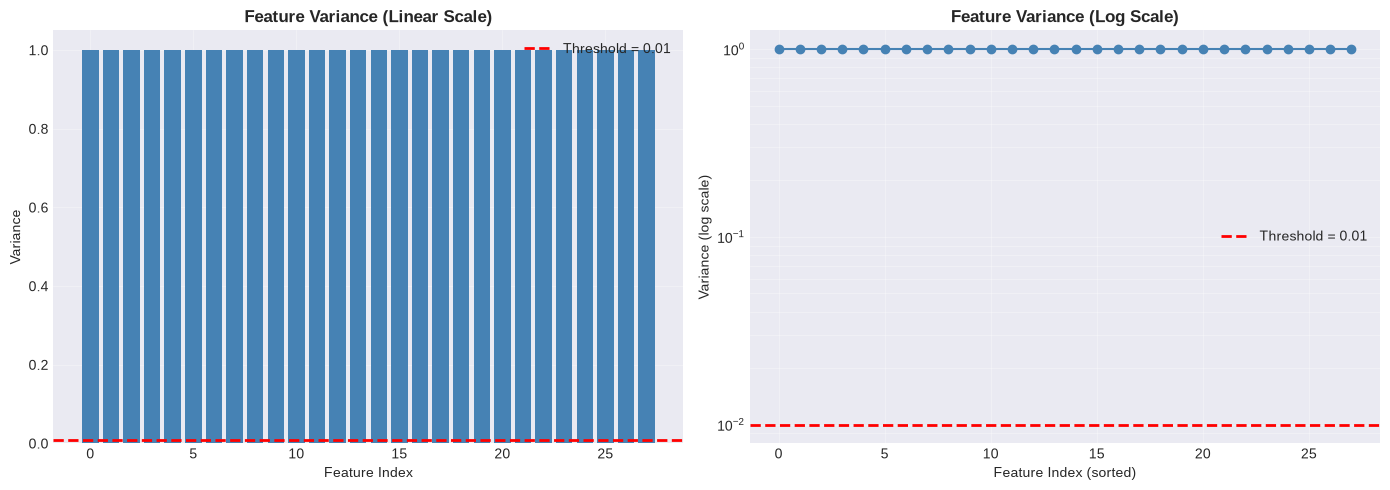

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

variance = np.var(X_normalized, axis=0)
print(f"Variance of each feature after normalization:\n{variance}")


print(f"Mean of each feature after normalization:\n{np.mean(X_normalized, axis=0)}")
print(f"Max of each feature after normalization:\n{np.max(X_normalized, axis=0)}")
print(f"Min of each feature after normalization:\n{np.min(X_normalized, axis=0)}")

threshold = 1e-2
low_variance_features = np.where(variance < threshold)[0]
print(f"Low variance features (variance < {threshold}): {low_variance_features}")

plotter.plot_feature_variance(variance, threshold)

## Analyze Feature Distributions by Class

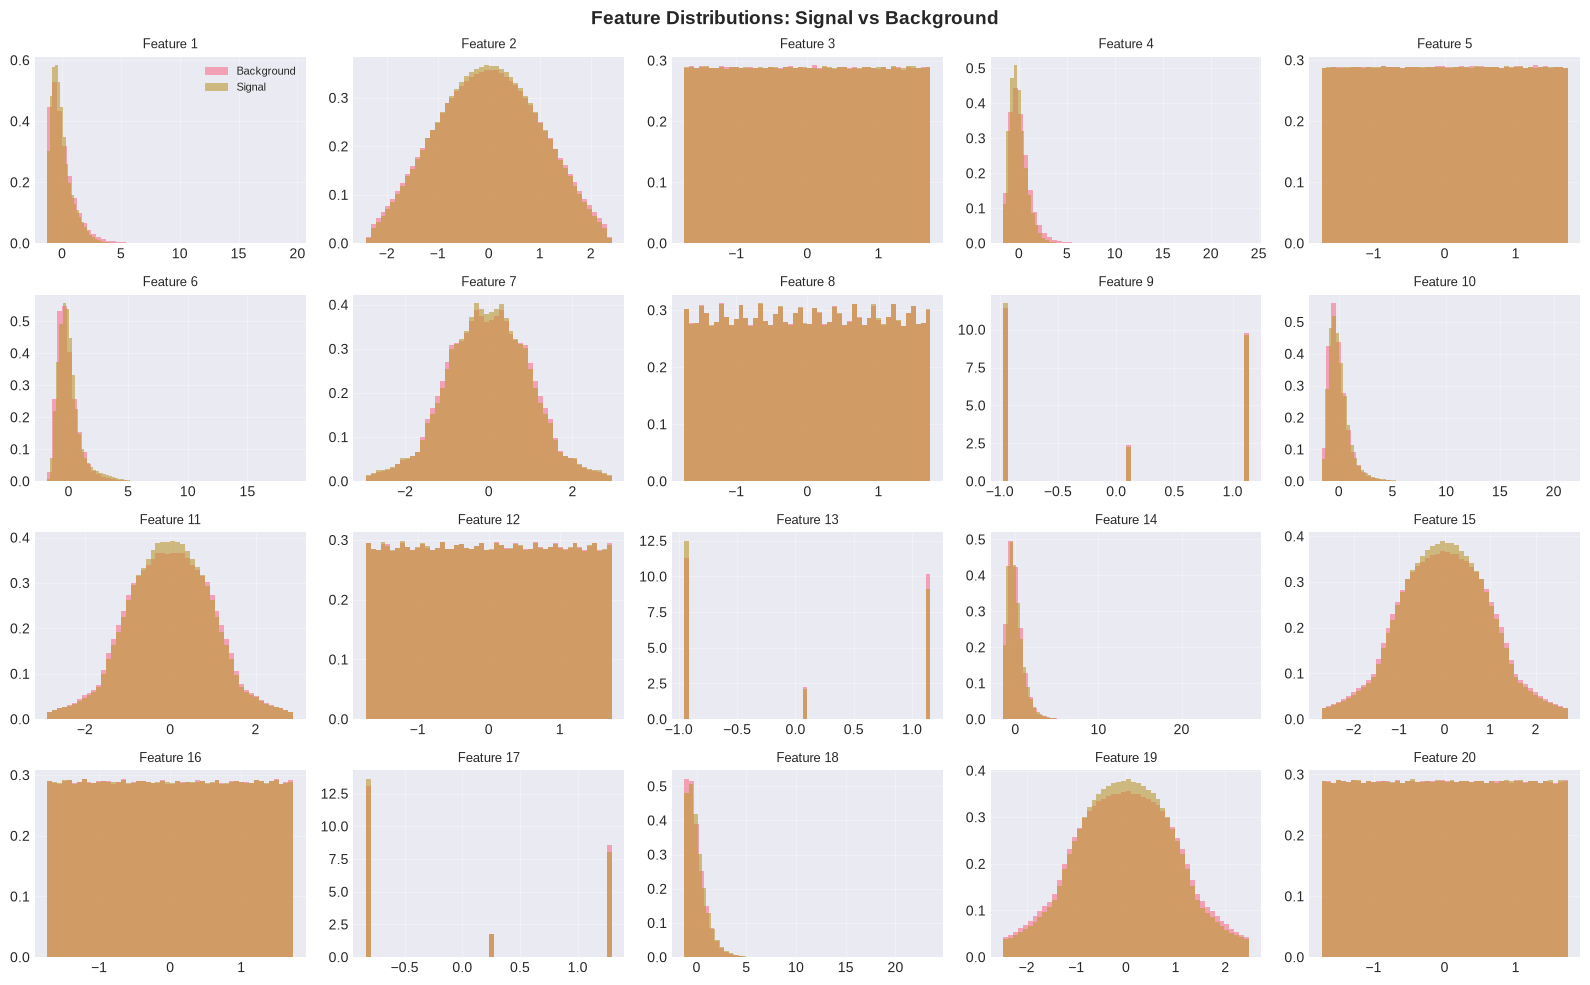

In [ ]:
plotter.plot_feature_distributions_by_class(X_normalized, y)

## Check Correlation Between Features

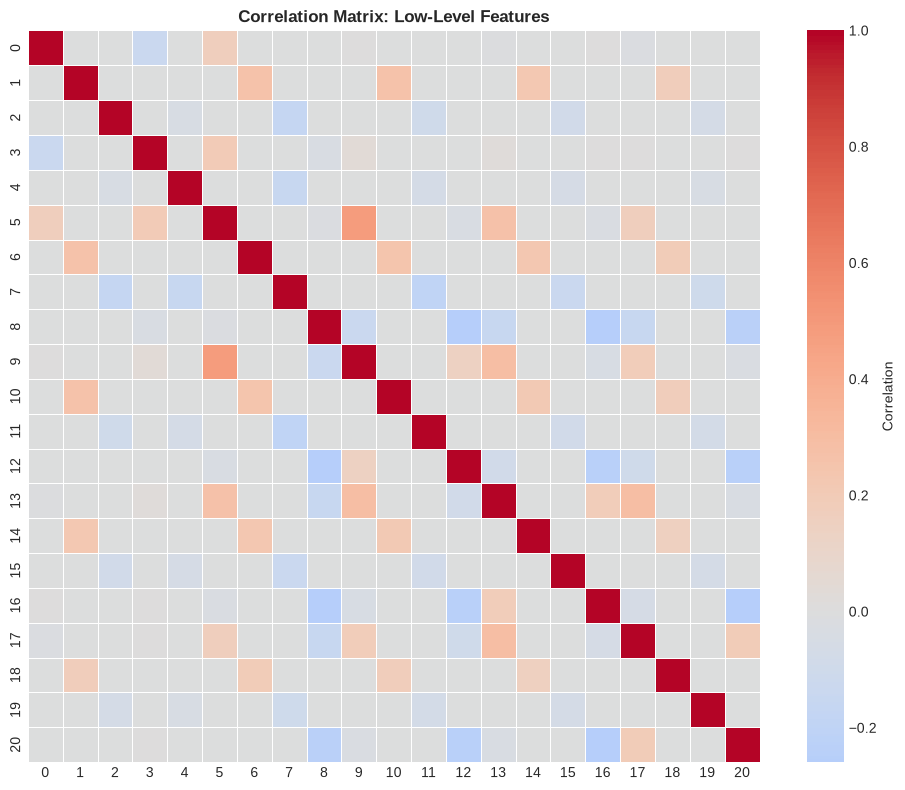

In [25]:
plotter.plot_correlation_matrix(X)

## Compare Low-Level vs High-Level Features

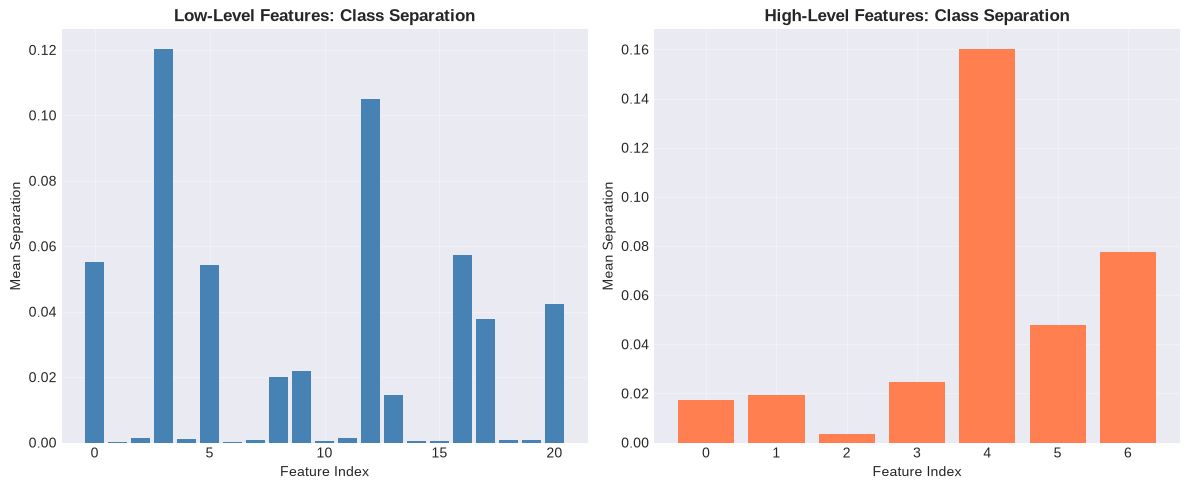

In [ ]:
plotter.plot_class_separation(X, y)

## PCA Visualization (2D Projection)

/home/moh/ws_idea/Higgs Boson Detection/src/plotting.py:191: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/moh/ws_idea/Higgs Boson Detection/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


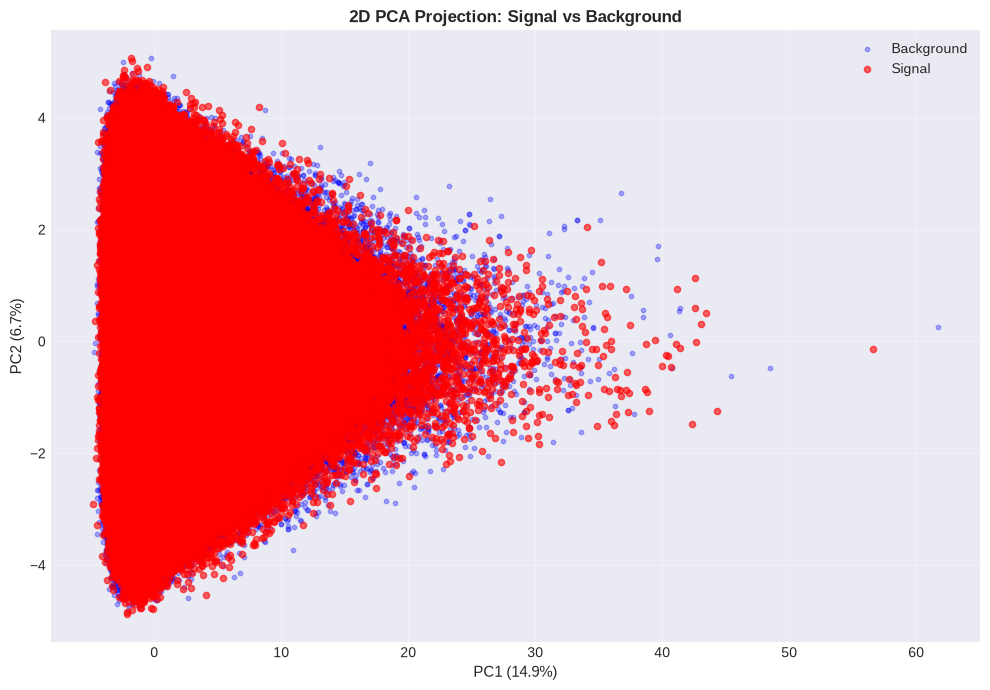

In [27]:
plotter.plot_pca_projection(X_normalized, y)

## Box Plots (Quartiles & Outliers)

In [36]:
def reload_modules():
    """Reload custom modules after editing."""
    importlib.reload(utils)
    importlib.reload(plotting)
    print("✓ Modules reloaded!")

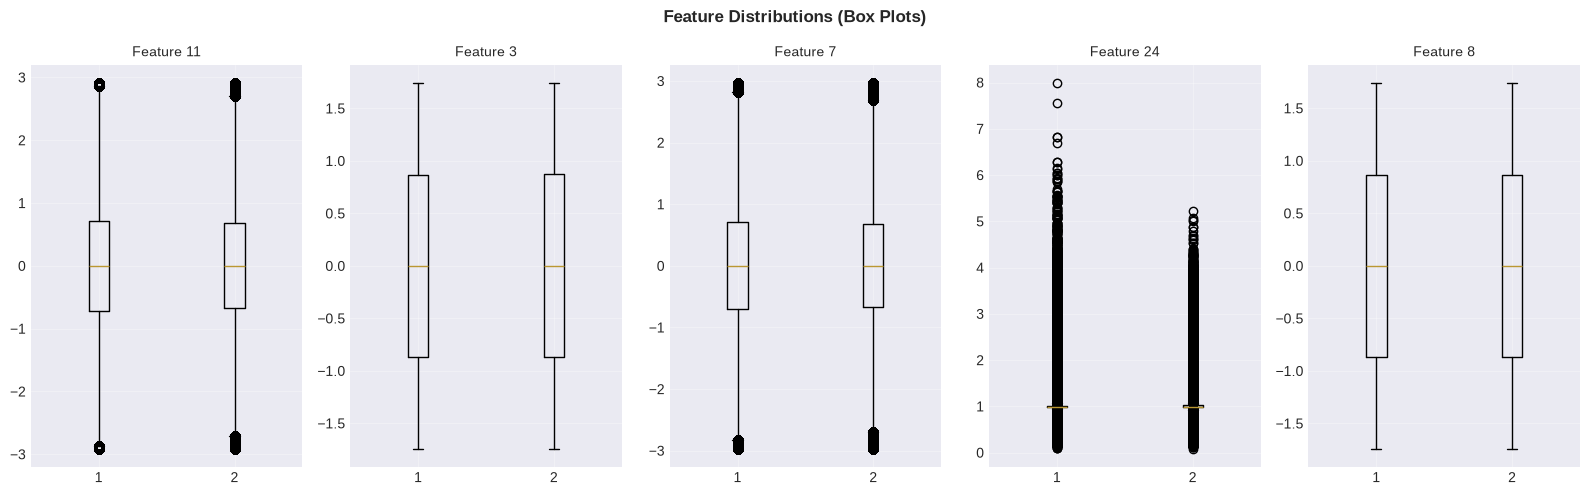

In [ ]:
plotter.plot_boxplot_features(X, y)

## Summary & Key Findings

In [6]:
statistical_summary(higgs_dataframe)

EDA SUMMARY

1. CLASS DISTRIBUTION:
   Background (0): 5,170,877 (47.0%)
   Signal (1): 5,829,123 (53.0%)
   Imbalance ratio: 1.13:1
   BALANCED DATA: Class weights optional

2. MISSING VALUES:
   Total missing: 0
 ✓ OK (data quality is excellent)

3. FEATURE VARIANCE:
   Min variance: 1.000000
   Max variance: 1.000000
   Mean variance: 1.000000
   Features with variance < 0.01: 0
   ✓ OK (all features have good variance)

4. OUTLIERS:
   Max value across features: 58.04
   Min value across features: -5.88
   Features with extreme outliers (|x| > 10): 13
   Extreme feature indices: [0, 3, 5, 9, 13, 17, 21, 22, 23, 24, 25, 26, 27]
   Use gradient clipping during training

5. CLASS SEPARABILITY:
   Mean separation between classes: 0.0317
   Weak separation (problem may be hard)

6. PREPROCESSING STRATEGY:
   ✓ Standardize features (StandardScaler)
   ✓ Stratified train/val/test split (preserve class distribution)
   ○ Class weights optional (data is balanced)
   ✓ Use gradient clipping 